# 01 — Cobertura do repositório IPEA (Fase 1)

Lê `data/interim/metadados.parquet` produzido por `python -m src.scraping`
e descreve o corpus disponível para decidir o corpus-alvo da Fase 2
(briefing §5, Fase 2, decisão inicial).

Critérios de sucesso (briefing §5, Fase 1): N total, N por tipo, min/max de ano.

In [1]:
from pathlib import Path

import pandas as pd

PARQUET = Path("../data/interim/metadados.parquet")
assert PARQUET.exists(), (
    f"{PARQUET} não existe. Rode antes:\n"
    "    uv run python -m src.scraping --limit 2\n"
    "(ou sem --limit para o corpus completo)."
)
df = pd.read_parquet(PARQUET)
print(f"Total: {len(df):,} documentos")
df.head(3)

Total: 17,943 documentos


,id,handle,titulo,resumo,autores,palavras_chave,tipo,ano,last_modified,last_modified_ts
0,5ea3ec93-ae81-4c4f-a82e-4dc4be8d66c1,https://repositorio.ipea.gov.br/handle/11058/2...,O Jogo de poder no Ministério da Agricultura d...,Este estudo investiga as disputas de poder e i...,,"Burocracia, Politização, Grupos de interesse, ...",Working paper,2026.0,2026-04-10T02:01:57.888000Z,1775786517
1,75910319-ce0f-40f2-89fb-c2f923bb2500,https://repositorio.ipea.gov.br/handle/11058/2...,Capacidades estatais municipais e o desempenho...,Qual a associação entre as capacidades estatai...,Pedro Lucas de Moura Palotti; Paulo de Tarso F...,"Capacidade Estatal, Transferências Voluntárias...",Preliminary Publication,2026.0,2026-04-09T02:02:50.775000Z,1775700170
2,1ac2460d-8654-44ec-90e8-f12315f7bc0e,https://repositorio.ipea.gov.br/handle/11058/2...,Operacionalizando a justiça climática: uma pro...,Este texto propõe um modelo para operacionaliz...,"Moraes, Rodrigo Fracalossi de","Justiça climática, Orçamento de carbono, Dívid...",Working paper,2026.0,2026-04-09T02:01:10.646000Z,1775700070


## Cobertura temporal

Ano mínimo: 88
Ano máximo: 2026
Sem ano: 376 (2.1%)


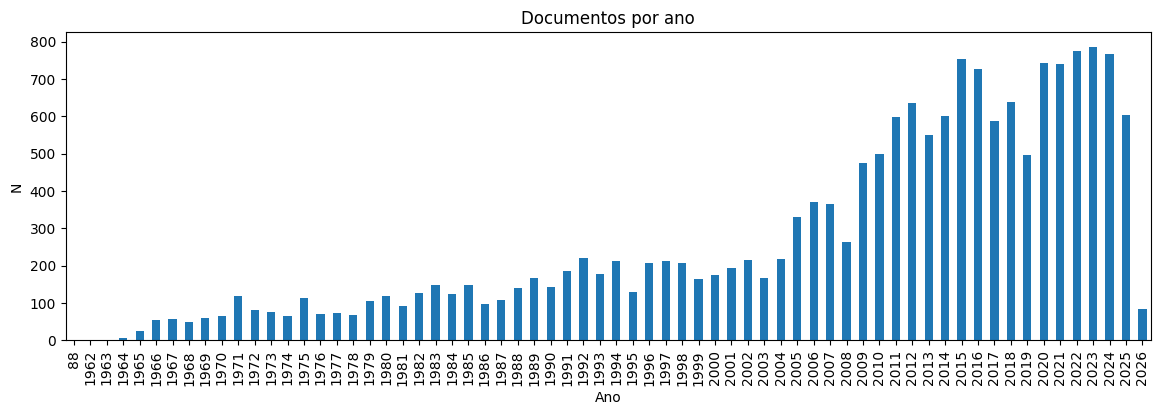

In [2]:
anos = df["ano"].dropna().astype(int)
print(f"Ano mínimo: {anos.min()}")
print(f"Ano máximo: {anos.max()}")
print(f"Sem ano: {df['ano'].isna().sum()} ({df['ano'].isna().mean():.1%})")
ax = anos.value_counts().sort_index().plot(
    kind="bar", figsize=(14, 4), title="Documentos por ano"
)
ax.set_xlabel("Ano")
ax.set_ylabel("N");

## Distribuição por tipo documental

In [3]:
tipos = df["tipo"].fillna("(sem tipo)").value_counts()
print(tipos.head(20).to_string())

tipo
Working paper              5015
Journal article            5003
Book                       2617
Book part                  2093
Journal                    1038
Report                      823
Journal Article             608
                            382
Researchers                 175
Eventos                      74
Joint Publications           29
Preliminary Publication      27
Series                       27
Organizational unit          12
Conference output             5
Policy Brief                  4
master thesis                 4
Newspaper article             2
Research Reports IPC-IG       2
Event                         2


## Cobertura de handle e resumo

Documentos sem `handle` não podem ter PDF baixado na Fase 2.

In [4]:
print(f"Com handle:  {df['handle'].notna().sum():>6} ({df['handle'].notna().mean():.1%})")
print(f"Com resumo:  {(df['resumo'] != '').sum():>6} ({(df['resumo'] != '').mean():.1%})")
print(f"Com autores: {(df['autores'] != '').sum():>6} ({(df['autores'] != '').mean():.1%})")

Com handle:   17931 (99.9%)
Com resumo:   17607 (98.1%)
Com autores:  14785 (82.4%)


## Top autores e palavras-chave

In [5]:
autores = (
    df["autores"].fillna("").str.split("; ").explode().str.strip()
)
autores = autores[autores != ""]
print("Top 30 autores:")
print(autores.value_counts().head(30).to_string())

Top 30 autores:
autores
Barros, Ricardo Paes de                     177
Instituto de Pesquisa Econômica Aplicada    168
Silva, Sandro Pereira                       139
Corseuil, Carlos Henrique Leite             121
Carvalho, Leonardo Mello de                 114
Vieira Filho, José Eustáquio Ribeiro        112
Moreira, Ajax Reynaldo Bello                106
Soares, Sergei Suarez Dillon                101
Lameiras, Maria Andreia Parente              99
Ministério do Trabalho e Emprego             98
Ramos, Lauro Roberto Albrecht                94
Mendonça, Rosane Silva Pinto de              89
Bahia, Luiz Dias                             81
De Negri, Fernanda                           81
Bonelli, Regis                               81
Camarano, Ana Amélia                         79
Castro, César Nunes de                       77
Motta, Ronaldo Seroa da                      76
Campos, André Gambier                        73
Furtado, Bernardo Alves                      71
Foguel, Miguel N

In [6]:
palavras = (
    df["palavras_chave"].fillna("").str.split(", ").explode().str.strip()
)
palavras = palavras[palavras != ""]
print("Top 50 palavras-chave:")
print(palavras.value_counts().head(50).to_string())

Top 50 palavras-chave:
palavras_chave
Políticas públicas                    1021
Mercado de trabalho                    785
Desenvolvimento regional               444
Desenvolvimento econômico              425
Desenvolvimento sustentável            308
Emprego                                300
Crescimento econômico                  289
Agricultura                            225
social protection                      205
Distribuição de renda                  204
Política econômica                     200
Planejamento econômico                 197
Desenvolvimento econômico e social     197
Pobreza                                191
Comércio internacional                 187
Infraestrutura                         183
Pesquisa econômica                     181
Covid-19                               181
Economia                               178
Inflação                               175
Educação                               172
Desenvolvimento social                 165
Inovações tecnol

## Cruzamento tipo × década

Base para a decisão de filtrar corpus-alvo na Fase 2.

In [7]:
df_com_ano = df.dropna(subset=["ano"]).copy()
df_com_ano["decada"] = (df_com_ano["ano"].astype(int) // 10) * 10
pivot = (
    df_com_ano.groupby(["decada", "tipo"]).size().unstack(fill_value=0)
)
pivot = pivot.loc[:, pivot.sum().sort_values(ascending=False).head(8).index]
pivot

tipo,Working paper,Journal article,Book,Book part,Journal,Report,Journal Article,
decada,,,,,,,,
80,0,0,0,0,0,0,0,1
1960,2,0,215,1,0,32,0,0
1970,15,226,449,26,25,88,0,0
1980,219,354,522,34,37,89,1,3
1990,525,272,632,139,104,62,74,38
2000,988,865,267,256,234,82,57,0
2010,2013,1925,431,798,454,252,48,100
2020,1253,1360,101,839,171,218,428,94
